In [97]:
print("hi")

hi


In [98]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.risk import (
    calculate_historical_losses,
    calculate_var_es_table,
    calculate_all_rolling_var,
)

In [99]:
Path.cwd()

WindowsPath('c:/Users/asus/OneDrive/Desktop/QFI Projects/Market Risk/notebooks')

In [100]:
PROJECT_ROOT = Path.cwd().parent

In [101]:
print(PROJECT_ROOT)

c:\Users\asus\OneDrive\Desktop\QFI Projects\Market Risk


In [102]:
portfolio_path = (
    PROJECT_ROOT
    / "data"
    / "portfolio"
    / "portfolio_daily.csv"
)

portfolio = pd.read_csv(
    portfolio_path,
    index_col=0,
    parse_dates=True,
)

portfolio.head()

,Portfolio Return,Portfolio P&L,Portfolio Value
Date,,,
2020-01-03,-0.009045,-9045.251511,9.909547e+05
2020-01-06,0.009246,9162.094279,1.000117e+06
2020-01-07,-0.000913,-913.191138,9.992037e+05
2020-01-08,0.009735,9727.329350,1.008931e+06
2020-01-09,0.009290,9372.541018,1.018304e+06


In [103]:
print(portfolio.shape)
print(portfolio.columns.tolist())

(1652, 3)
['Portfolio Return', 'Portfolio P&L', 'Portfolio Value']


In [104]:
required_columns = {
    "Portfolio Value",
    "Portfolio P&L",
    "Portfolio Return",
}

missing_columns = required_columns - set(portfolio.columns)

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

In [105]:
portfolio = portfolio.sort_index()

if portfolio.index.has_duplicates:
    raise ValueError(
        "Portfolio data contains duplicate dates."
    )

In [106]:
portfolio_returns = (
    portfolio["Portfolio Return"]
    .dropna()
)

print("Observations:", len(portfolio_returns))
print("Missing:", portfolio_returns.isna().sum())
print("Infinite:", np.isinf(portfolio_returns).sum())

Observations: 1652
Missing: 0
Infinite: 0


In [107]:
if portfolio_returns.empty:
    raise ValueError(
        "Portfolio return series is empty."
    )

if portfolio_returns.isna().any():
    raise ValueError(
        "Portfolio returns contain NaN values."
    )

if not np.isfinite(
    portfolio_returns.to_numpy()
).all():
    raise ValueError(
        "Portfolio returns contain infinite values."
    )

In [108]:
MINIMUM_OBSERVATIONS = 750

if len(portfolio_returns) < MINIMUM_OBSERVATIONS:
    raise ValueError(
        f"Phase 4 requires at least "
        f"{MINIMUM_OBSERVATIONS} observations. "
        f"Found {len(portfolio_returns)}."
    )

print(
    f"Phase 4 data validation passed: "
    f"{len(portfolio_returns)} observations."
)

Phase 4 data validation passed: 1652 observations.


In [109]:
historical_losses = calculate_historical_losses(
    portfolio_returns
)

historical_losses.describe()

count    1652.000000
mean       -0.000975
std         0.017080
min        -0.118835
25%        -0.009923
50%        -0.001594
75%         0.006551
max         0.148607
Name: Loss, dtype: float64

In [110]:
worst_losses = (
    historical_losses
    .sort_values(ascending=False)
    .head(20)
)

worst_losses

Date
2020-03-16    0.148607
2020-03-12    0.103031
2020-03-09    0.084441
2025-04-03    0.064508
2022-09-13    0.062256
2020-02-27    0.061482
2025-04-04    0.060784
2020-09-03    0.058572
2020-09-08    0.058545
2020-06-11    0.057718
2020-03-18    0.054814
2022-05-05    0.054683
2020-04-01    0.051858
2022-05-18    0.051495
2020-02-24    0.051333
2022-06-13    0.050461
2022-04-29    0.050097
2022-05-09    0.048731
2020-10-28    0.047347
2022-08-26    0.047128
Name: Loss, dtype: float64

In [111]:
current_portfolio_value = (
    portfolio["Portfolio Value"]
    .dropna()
    .iloc[-1]
)

print(
    f"Current portfolio value: "
    f"{current_portfolio_value:,.2f}"
)

Current portfolio value: 3,929,222.23


In [112]:
if current_portfolio_value <= 0:
    raise ValueError(
        "Current portfolio value must be positive."
    )

In [113]:
var_es_results = calculate_var_es_table(
    returns=portfolio_returns,
    portfolio_value=current_portfolio_value,
)

var_es_results

,Window,Confidence,VaR,Expected Shortfall,VaR Amount,ES Amount
0,250,0.950,0.016154,0.023206,63472.065864,91180.064590
1,250,0.990,0.026519,0.030097,104198.635689,118258.771079
2,250,0.995,0.028921,0.031796,113637.657036,124931.866699
3,500,0.950,0.021387,0.032380,84036.024409,127227.151908
4,500,0.990,0.034468,0.050779,135431.363041,199521.326247
5,500,0.995,0.043480,0.056628,170841.076908,222502.620063
6,750,0.950,0.020403,0.029488,80169.661793,115866.510451
7,750,0.990,0.033223,0.045184,130539.593774,177539.428378
8,750,0.995,0.041839,0.053057,164394.046027,208473.668313


In [114]:
display_results = var_es_results.copy()

display_results["VaR (%)"] = (
    display_results["VaR"] * 100
)

display_results["ES (%)"] = (
    display_results["Expected Shortfall"] * 100
)

display_results

,Window,Confidence,VaR,Expected Shortfall,VaR Amount,ES Amount,VaR (%),ES (%)
0,250,0.950,0.016154,0.023206,63472.065864,91180.064590,1.615385,2.320563
1,250,0.990,0.026519,0.030097,104198.635689,118258.771079,2.651890,3.009725
2,250,0.995,0.028921,0.031796,113637.657036,124931.866699,2.892116,3.179557
3,500,0.950,0.021387,0.032380,84036.024409,127227.151908,2.138745,3.237973
4,500,0.990,0.034468,0.050779,135431.363041,199521.326247,3.446773,5.077883
5,500,0.995,0.043480,0.056628,170841.076908,222502.620063,4.347962,5.662765
6,750,0.950,0.020403,0.029488,80169.661793,115866.510451,2.040344,2.948841
7,750,0.990,0.033223,0.045184,130539.593774,177539.428378,3.322276,4.518437
8,750,0.995,0.041839,0.053057,164394.046027,208473.668313,4.183883,5.305724


In [115]:
display_results = display_results.round(
    {
        "VaR": 6,
        "Expected Shortfall": 6,
        "VaR (%)": 3,
        "ES (%)": 3,
        "VaR Amount": 2,
        "ES Amount": 2,
    }
)

display_results

,Window,Confidence,VaR,Expected Shortfall,VaR Amount,ES Amount,VaR (%),ES (%)
0,250,0.950,0.016154,0.023206,63472.07,91180.06,1.615,2.321
1,250,0.990,0.026519,0.030097,104198.64,118258.77,2.652,3.010
2,250,0.995,0.028921,0.031796,113637.66,124931.87,2.892,3.180
3,500,0.950,0.021387,0.032380,84036.02,127227.15,2.139,3.238
4,500,0.990,0.034468,0.050779,135431.36,199521.33,3.447,5.078
5,500,0.995,0.043480,0.056628,170841.08,222502.62,4.348,5.663
6,750,0.950,0.020403,0.029488,80169.66,115866.51,2.040,2.949
7,750,0.990,0.033223,0.045184,130539.59,177539.43,3.322,4.518
8,750,0.995,0.041839,0.053057,164394.05,208473.67,4.184,5.306


In [116]:
assert (
    var_es_results["Expected Shortfall"]
    >= var_es_results["VaR"]
).all()

print("✓ ES >= VaR")

✓ ES >= VaR


In [117]:
for window in [250, 500, 750]:

    subset = var_es_results[
        var_es_results["Window"] == window
    ].sort_values("Confidence")

    var_values = subset["VaR"].to_numpy()

    assert var_values[2] >= var_values[1]
    assert var_values[1] >= var_values[0]

print("✓ VaR increases with confidence level")

✓ VaR increases with confidence level


In [118]:
expected_combinations = {
    (window, confidence)
    for window in [250, 500, 750]
    for confidence in [0.95, 0.99, 0.995]
}

actual_combinations = {
    (row["Window"], row["Confidence"])
    for _, row in var_es_results.iterrows()
}

assert expected_combinations == actual_combinations

print("✓ All 9 VaR/ES combinations calculated")

✓ All 9 VaR/ES combinations calculated


In [121]:
risk_output_path = (
    PROJECT_ROOT
    / "data"
    / "risk"
)

risk_output_path.mkdir(parents=True, exist_ok=True)

In [122]:
var_es_results.to_csv(
    risk_output_path / "historical_var_es.csv",
    index=False,
)

print(
    "Saved:",
    risk_output_path / "historical_var_es.csv"
)

Saved: c:\Users\asus\OneDrive\Desktop\QFI Projects\Market Risk\data\risk\historical_var_es.csv


In [123]:
rolling_var = calculate_all_rolling_var(
    portfolio_returns
)

rolling_var.head()

,VaR_95_250D,VaR_99_250D,VaR_99_5_250D,VaR_95_500D,VaR_99_500D,VaR_99_5_500D,VaR_95_750D,VaR_99_750D,VaR_99_5_750D
Date,,,,,,,,,
2020-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [124]:
rolling_var.to_csv(
    risk_output_path / "rolling_var.csv"
)

print(
    "Saved:",
    risk_output_path / "rolling_var.csv"
)

Saved: c:\Users\asus\OneDrive\Desktop\QFI Projects\Market Risk\data\risk\rolling_var.csv


In [125]:
first_249 = rolling_var[
    "VaR_95_250D"
].iloc[:249]

assert first_249.isna().all()

assert rolling_var[
    "VaR_95_250D"
].iloc[249:].notna().all()

print("✓ 250-day rolling VaR validation passed")

✓ 250-day rolling VaR validation passed


In [128]:
assert rolling_var[
    "VaR_99_500D"
].iloc[:499].isna().all()

assert rolling_var[
    "VaR_95_500D"
].iloc[499:].notna().all()

print("✓ 500-day rolling VaR validation passed")

✓ 500-day rolling VaR validation passed


In [129]:
assert rolling_var[
    "VaR_95_750D"
].iloc[:749].isna().all()

assert rolling_var[
    "VaR_95_750D"
].iloc[749:].notna().all()

print("✓ 750-day rolling VaR validation passed")

✓ 750-day rolling VaR validation passed


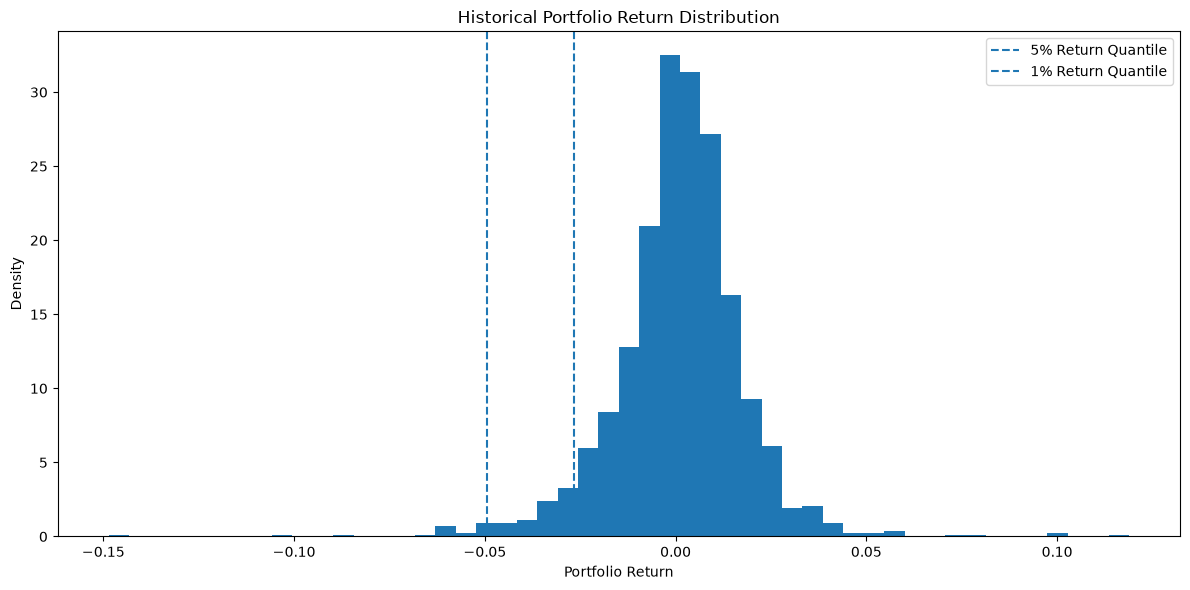

In [130]:
plt.figure(figsize=(12, 6))

plt.hist(
    portfolio_returns,
    bins=50,
    density=True,
)

plt.axvline(
    portfolio_returns.quantile(0.05),
    linestyle="--",
    label="5% Return Quantile",
)

plt.axvline(
    portfolio_returns.quantile(0.01),
    linestyle="--",
    label="1% Return Quantile",
)

plt.title(
    "Historical Portfolio Return Distribution"
)

plt.xlabel("Portfolio Return")
plt.ylabel("Density")

plt.legend()
plt.tight_layout()
plt.show()

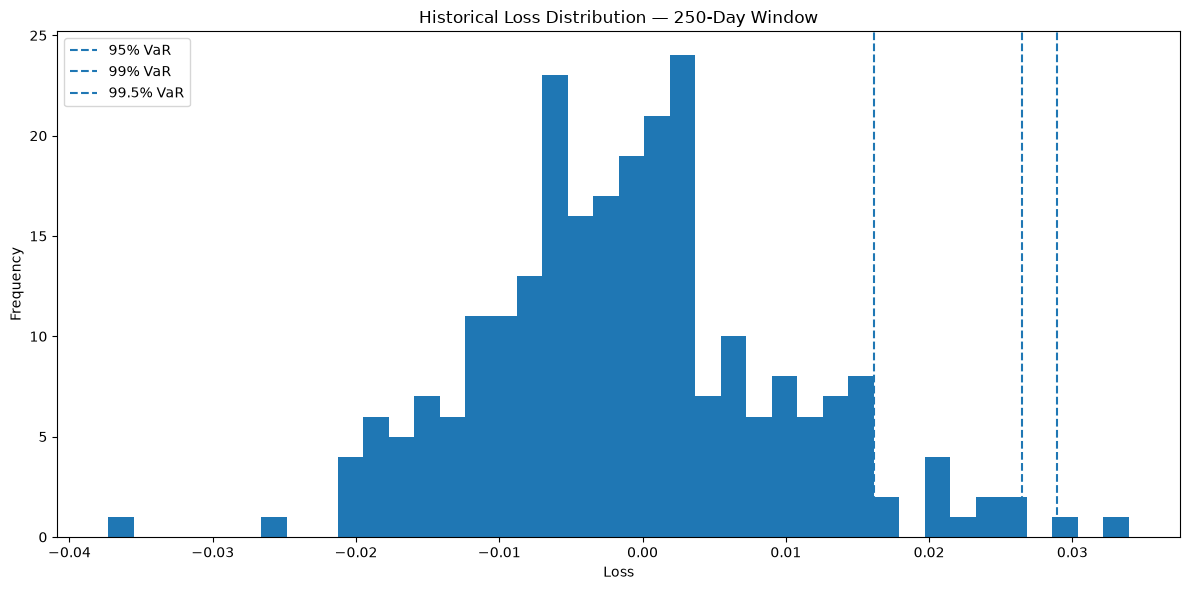

In [131]:
window = 250

latest_losses = (
    -portfolio_returns.iloc[-window:]
)

var_95 = latest_losses.quantile(0.95)
var_99 = latest_losses.quantile(0.99)
var_995 = latest_losses.quantile(0.995)

plt.figure(figsize=(12, 6))

plt.hist(
    latest_losses,
    bins=40,
)

plt.axvline(
    var_95,
    linestyle="--",
    label="95% VaR",
)

plt.axvline(
    var_99,
    linestyle="--",
    label="99% VaR",
)

plt.axvline(
    var_995,
    linestyle="--",
    label="99.5% VaR",
)

plt.title(
    "Historical Loss Distribution — 250-Day Window"
)

plt.xlabel("Loss")
plt.ylabel("Frequency")

plt.legend()
plt.tight_layout()
plt.show()

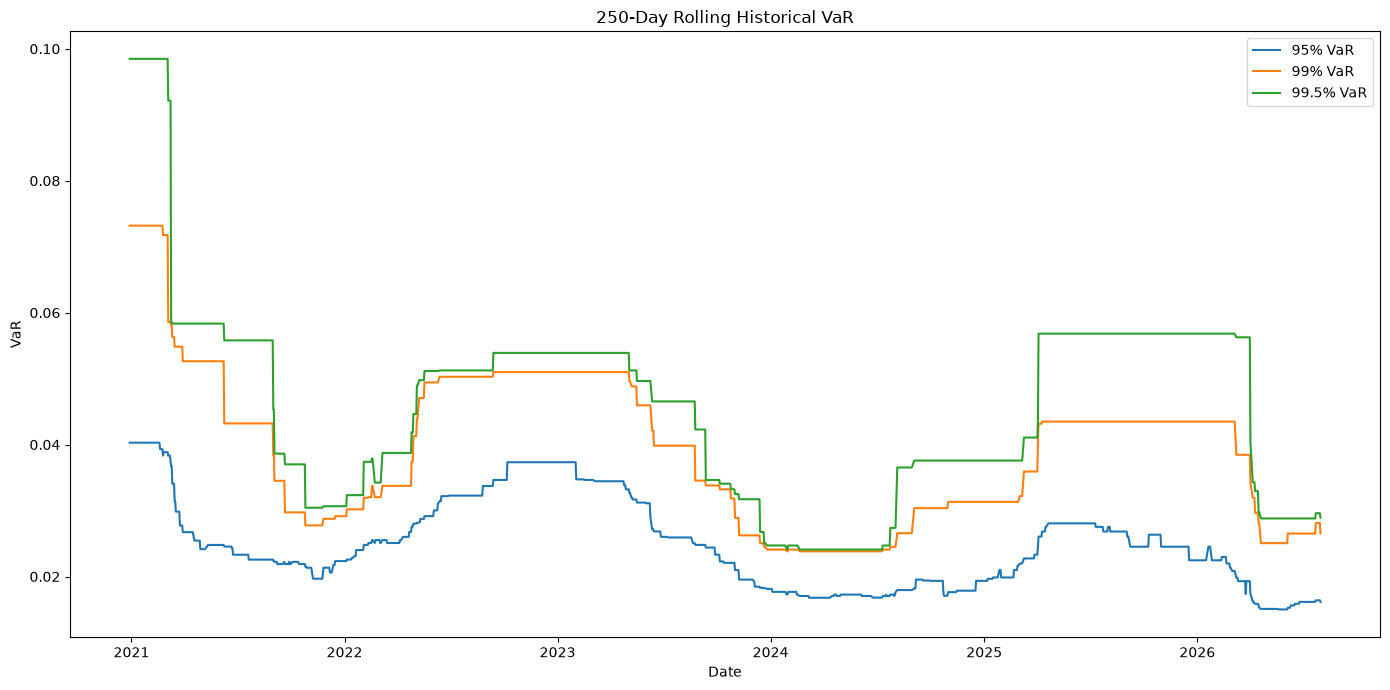

In [135]:
plt.figure(figsize=(14, 7))

plt.plot(
    rolling_var["VaR_95_250D"],
    label="95% VaR",
)

plt.plot(
    rolling_var["VaR_99_250D"],
    label="99% VaR",
)

plt.plot(
    rolling_var["VaR_99_5_250D"],
    label="99.5% VaR",
)

plt.title(
    "250-Day Rolling Historical VaR"
)

plt.xlabel("Date")
plt.ylabel("VaR")

plt.legend()
plt.tight_layout()
plt.show()

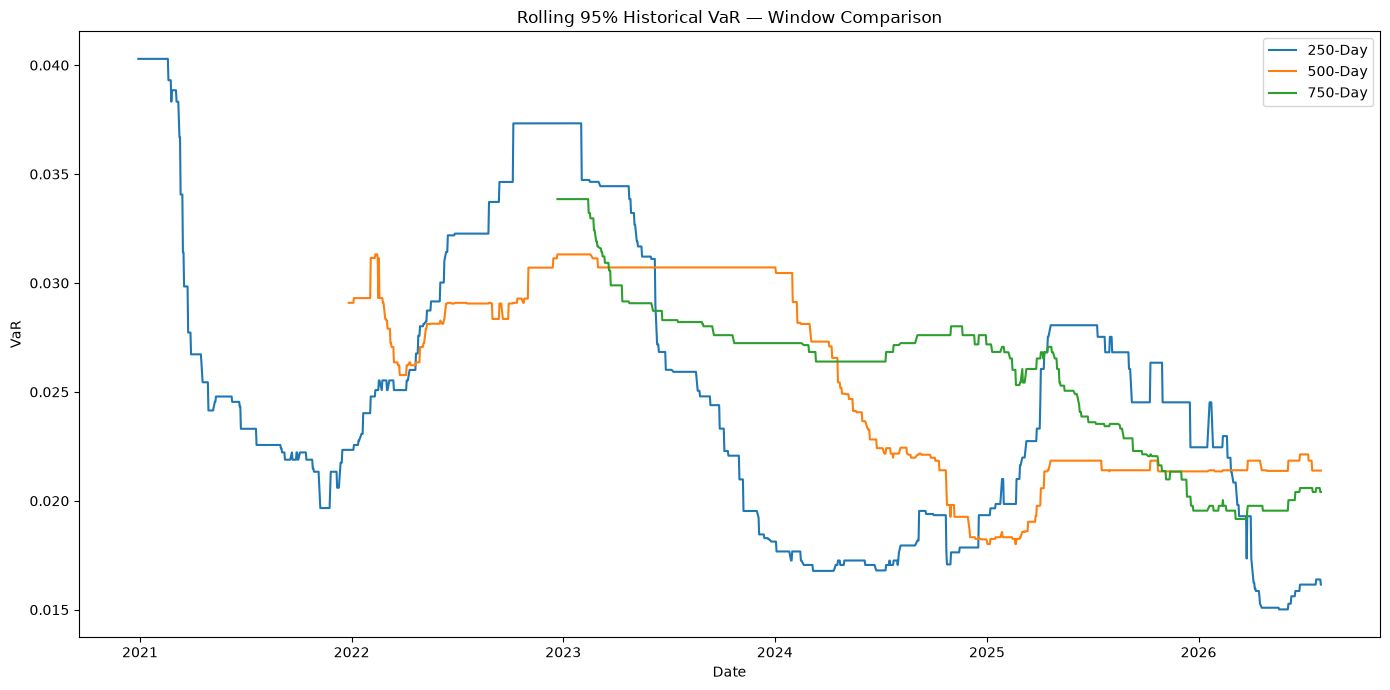

In [136]:
plt.figure(figsize=(14, 7))

plt.plot(
    rolling_var["VaR_95_250D"],
    label="250-Day",
)

plt.plot(
    rolling_var["VaR_95_500D"],
    label="500-Day",
)

plt.plot(
    rolling_var["VaR_95_750D"],
    label="750-Day",
)

plt.title(
    "Rolling 95% Historical VaR — "
    "Window Comparison"
)

plt.xlabel("Date")
plt.ylabel("VaR")

plt.legend()
plt.tight_layout()
plt.show()

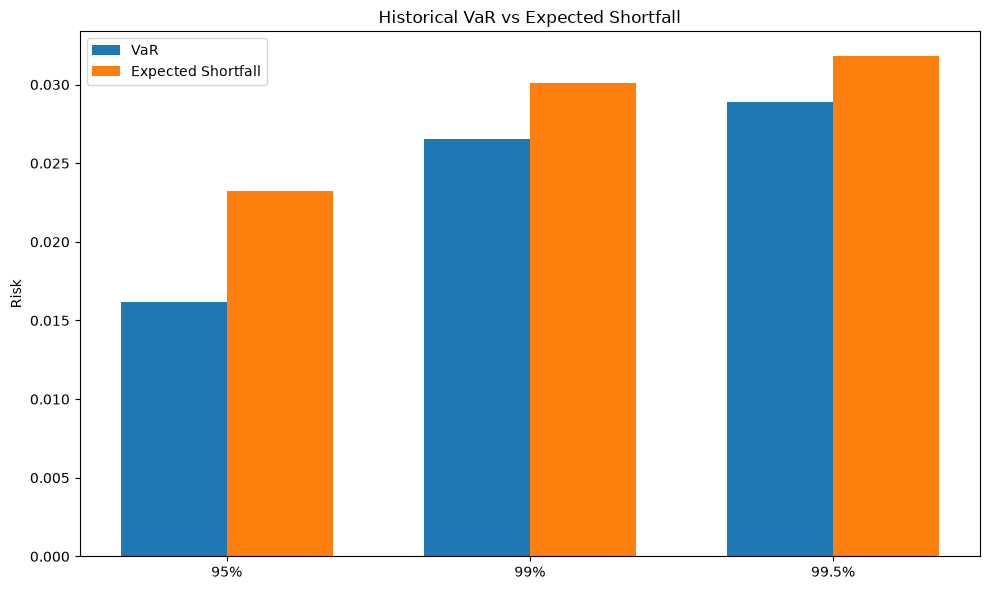

In [137]:
comparison = (
    var_es_results[
        var_es_results["Window"] == 250
    ]
    .copy()
)

comparison["Confidence Label"] = (
    comparison["Confidence"]
    .map(
        {
            0.95: "95%",
            0.99: "99%",
            0.995: "99.5%",
        }
    )
)

x = np.arange(len(comparison))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    comparison["VaR"],
    width,
    label="VaR",
)

plt.bar(
    x + width / 2,
    comparison["Expected Shortfall"],
    width,
    label="Expected Shortfall",
)

plt.xticks(
    x,
    comparison["Confidence Label"],
)

plt.ylabel("Risk")
plt.title(
    "Historical VaR vs Expected Shortfall"
)

plt.legend()
plt.tight_layout()
plt.show()

In [138]:
"""
Tests for Phase 4 Historical Simulation VaR and ES.
"""

import numpy as np
import pandas as pd
import pytest

from src.risk import (
    calculate_all_rolling_var,
    calculate_historical_es,
    calculate_historical_losses,
    calculate_historical_var,
    calculate_var_es_table,
)


def deterministic_returns(n: int = 750) -> pd.Series:
    """
    Generate deterministic portfolio returns.

    No random numbers are used so tests are reproducible.
    """

    values = np.tile(
        np.array(
            [
                -0.10,
                -0.08,
                -0.06,
                -0.05,
                -0.04,
                -0.03,
                -0.02,
                -0.01,
                0.01,
                0.02,
                0.03,
                0.04,
            ]
        ),
        n // 12 + 1,
    )[:n]

    dates = pd.date_range(
        start="2020-01-01",
        periods=n,
        freq="B",
    )

    return pd.Series(
        values,
        index=dates,
        name="Portfolio Return",
    )


def test_historical_losses():
    returns = pd.Series(
        [0.01, -0.02, 0.03]
    )

    losses = calculate_historical_losses(
        returns
    )

    expected = pd.Series(
        [-0.01, 0.02, -0.03],
        name="Loss",
    )

    pd.testing.assert_series_equal(
        losses,
        expected,
    )


def test_var_requires_enough_observations():
    returns = pd.Series(
        np.zeros(100)
    )

    with pytest.raises(ValueError):
        calculate_historical_var(
            returns,
            confidence_level=0.95,
            window=250,
        )


def test_invalid_window():
    returns = deterministic_returns()

    with pytest.raises(ValueError):
        calculate_historical_var(
            returns,
            confidence_level=0.95,
            window=100,
        )


def test_invalid_confidence_level():
    returns = deterministic_returns()

    with pytest.raises(ValueError):
        calculate_historical_var(
            returns,
            confidence_level=0.90,
            window=250,
        )


def test_nan_returns_are_rejected():
    returns = deterministic_returns()

    returns.iloc[10] = np.nan

    with pytest.raises(ValueError):
        calculate_historical_var(
            returns,
            confidence_level=0.95,
            window=250,
        )


def test_infinite_returns_are_rejected():
    returns = deterministic_returns()

    returns.iloc[10] = np.inf

    with pytest.raises(ValueError):
        calculate_historical_var(
            returns,
            confidence_level=0.95,
            window=250,
        )


def test_duplicate_dates_are_rejected():
    returns = deterministic_returns()

    returns.index = returns.index.where(
        np.arange(len(returns)) != 10,
        returns.index[9],
    )

    with pytest.raises(ValueError):
        calculate_historical_var(
            returns,
            confidence_level=0.95,
            window=250,
        )


def test_var_is_non_negative():
    returns = deterministic_returns()

    var = calculate_historical_var(
        returns,
        confidence_level=0.95,
        window=250,
    )

    assert var >= 0


def test_es_is_greater_than_or_equal_to_var():
    returns = deterministic_returns()

    var = calculate_historical_var(
        returns,
        confidence_level=0.95,
        window=250,
    )

    es = calculate_historical_es(
        returns,
        confidence_level=0.95,
        window=250,
    )

    assert es >= var


def test_var_increases_with_confidence():
    returns = deterministic_returns()

    var_95 = calculate_historical_var(
        returns,
        confidence_level=0.95,
        window=250,
    )

    var_99 = calculate_historical_var(
        returns,
        confidence_level=0.99,
        window=250,
    )

    var_995 = calculate_historical_var(
        returns,
        confidence_level=0.995,
        window=250,
    )

    assert var_99 >= var_95
    assert var_995 >= var_99


def test_var_es_table_has_nine_rows():
    returns = deterministic_returns()

    results = calculate_var_es_table(
        returns
    )

    assert len(results) == 9


def test_var_es_table_has_expected_columns():
    returns = deterministic_returns()

    results = calculate_var_es_table(
        returns
    )

    expected_columns = {
        "Window",
        "Confidence",
        "VaR",
        "Expected Shortfall",
    }

    assert expected_columns.issubset(
        results.columns
    )


def test_rolling_var_columns():
    returns = deterministic_returns()

    rolling = calculate_all_rolling_var(
        returns
    )

    expected_columns = {
        "VaR_95_250D",
        "VaR_99_250D",
        "VaR_99_5_250D",
        "VaR_95_500D",
        "VaR_99_500D",
        "VaR_99_5_500D",
        "VaR_95_750D",
        "VaR_99_750D",
        "VaR_99_5_750D",
    }

    assert expected_columns == set(
        rolling.columns
    )


def test_rolling_var_has_expected_nan_period():
    returns = deterministic_returns()

    rolling = calculate_all_rolling_var(
        returns
    )

    assert rolling[
        "VaR_95_250D"
    ].iloc[:249].isna().all()

    assert rolling[
        "VaR_95_250D"
    ].iloc[249:].notna().all()

    assert rolling[
        "VaR_95_500D"
    ].iloc[:499].isna().all()

    assert rolling[
        "VaR_95_750D"
    ].iloc[:749].isna().all()